In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
import chardet
with open('Order Book 2024 copied.csv', 'rb') as f:
    raw = f.read(500000) 

det = chardet.detect(raw)
print(det) 
df = pd.read_csv("Orderbook from May'23 to May'25-R1.csv", encoding=det['encoding'])

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [3]:
df['ORDER DATE'] = pd.to_datetime(df['ORDER DATE'])
df = df.sort_values('ORDER DATE')

In [4]:
df['Month'] = df['ORDER DATE'].dt.month
df['Year'] = df['ORDER DATE'].dt.year
#df['dayofweek'] = df['ORDER DATE'].dt.dayofweek
df['quarter'] = df['ORDER DATE'].dt.quarter

In [5]:
# Filter to include data only up to March 2025
df = df[(df['Year'] < 2025) | ((df['Year'] == 2025) & (df['Month'] <= 3))]

In [6]:
df.shape

(7569, 38)

C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Order Qty in MT', ylabel='Count'>

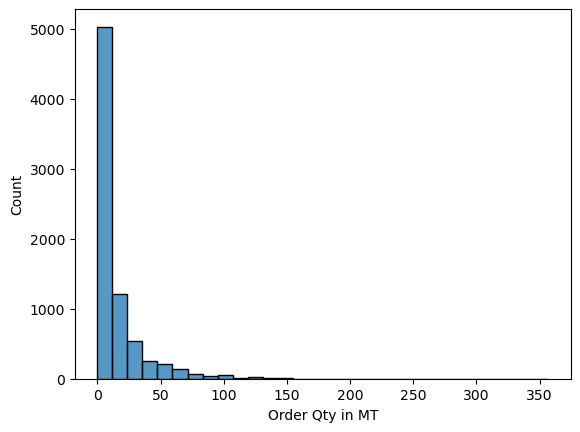

In [7]:
import seaborn as sns
sns.histplot(df['Order Qty in MT'], bins=30)

In [8]:
#df['log_qty'] = np.log1p(df['Order Qty in MT'])

In [9]:
#sns.histplot(df['log_qty'], bins=30)

In [10]:
monthly_growth = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

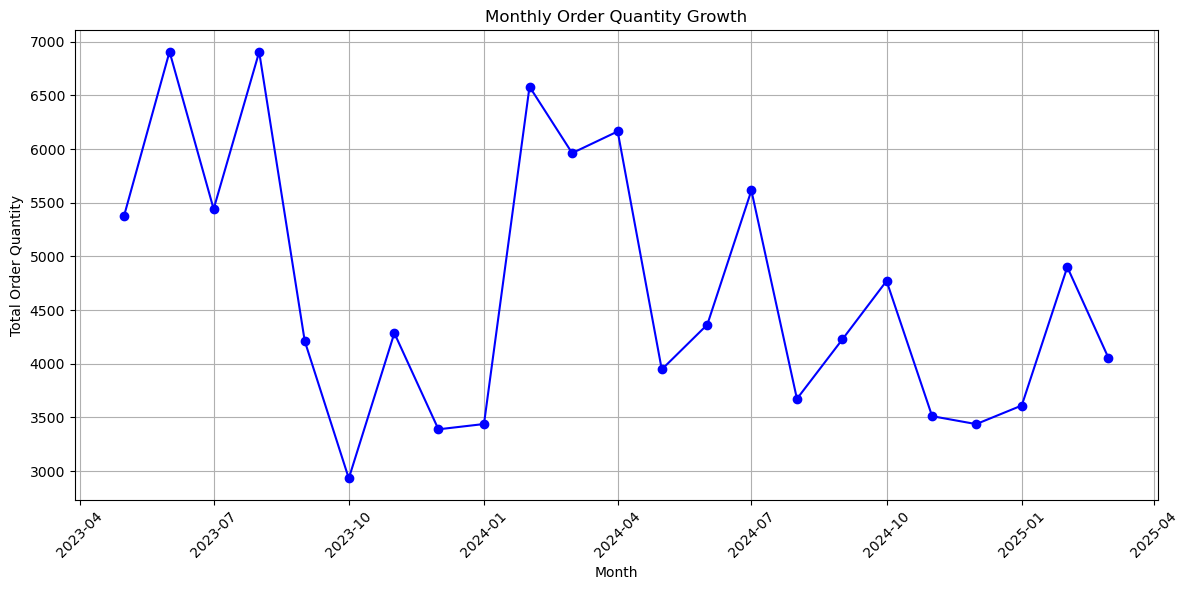

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_growth['ORDER DATE'], monthly_growth['Order Qty in MT'], marker='o', color='blue')
plt.title("Monthly Order Quantity Growth")
plt.xlabel("Month")
plt.ylabel("Total Order Quantity")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sonam Gupta\AppData\Local\Temp\ipykernel_11544\4207524108.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


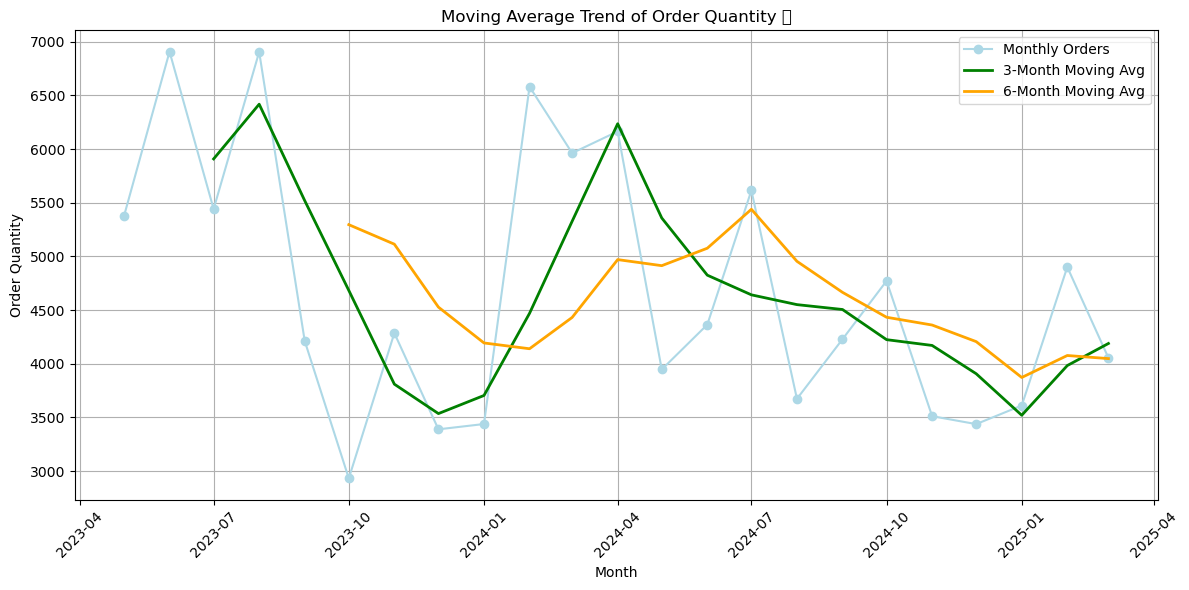

In [ ]:
monthly_data = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

monthly_data['MA_3'] = monthly_data['Order Qty in MT'].rolling(window=3).mean()
monthly_data['MA_6'] = monthly_data['Order Qty in MT'].rolling(window=6).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_data['ORDER DATE'], monthly_data['Order Qty in MT'], label='Monthly Orders', color='lightblue', marker='o')
plt.plot(monthly_data['ORDER DATE'], monthly_data['MA_3'], label='3-Month Moving Avg', color='green', linewidth=2)
plt.plot(monthly_data['ORDER DATE'], monthly_data['MA_6'], label='6-Month Moving Avg', color='orange', linewidth=2)

plt.title('Moving Average Trend of Order Quantity 📊')
plt.xlabel('Month')
plt.ylabel('Order Quantity')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sonam Gupta\AppData\Local\Temp\ipykernel_11544\1632482362.py:28: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from current font.
  plt.tight_layout()
C:\Users\Sonam Gupta\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


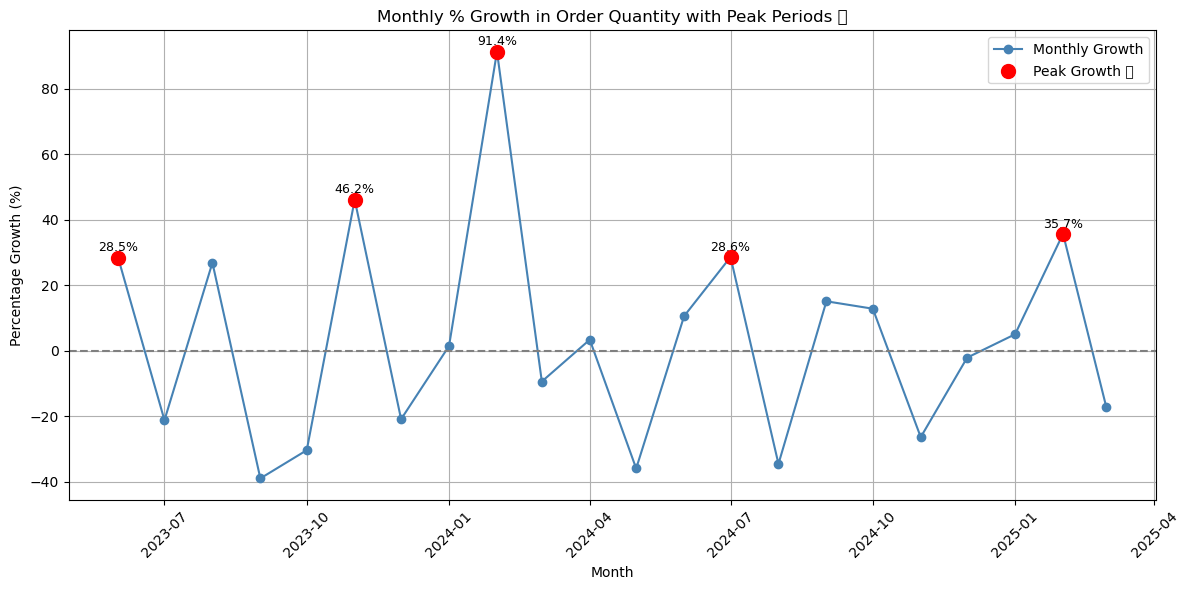

In [ ]:
monthly_qty = df.groupby(pd.Grouper(key='ORDER DATE', freq='MS'))['Order Qty in MT'].sum().reset_index()

monthly_qty['pct_growth'] = monthly_qty['Order Qty in MT'].pct_change() * 100

top_growth = monthly_qty.nlargest(5, 'pct_growth')

plt.figure(figsize=(12, 6))
plt.plot(monthly_qty['ORDER DATE'], monthly_qty['pct_growth'], marker='o', linestyle='-', label='Monthly Growth', color='steelblue')

plt.scatter(top_growth['ORDER DATE'], top_growth['pct_growth'], color='red', s=100, label='Peak Growth 🚩', zorder=5)

for i, row in top_growth.iterrows():
    plt.text(row['ORDER DATE'], row['pct_growth'] + 1, f"{row['pct_growth']:.1f}%", ha='center', va='bottom', fontsize=9)

plt.title("Monthly % Growth in Order Quantity with Peak Periods 🚩")
plt.xlabel("Month")
plt.ylabel("Percentage Growth (%)")
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')  
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
#df['log_qty'] 

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7569 entries, 0 to 5007
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   PLANT                   7569 non-null   int64         
 1   ORDER DATE              7569 non-null   datetime64[ns]
 2   MONTH YEAR              7569 non-null   object        
 3   PO DATE                 4864 non-null   object        
 4   SALES DOC TYPE          7569 non-null   object        
 5   Ageing Days             7569 non-null   int64         
 6   CREATOR                 5008 non-null   object        
 7   SALES ORDER NO.         7569 non-null   int64         
 8   Sales Document Item     7569 non-null   int64         
 9   PO NO.                  5008 non-null   object        
 10  City Code Description   7527 non-null   object        
 11  SALES OFFICE            7507 non-null   object        
 12  SOLD. CUST. NAME        7332 non-null   object       

In [16]:
df.shape

(7569, 38)

In [17]:
x='boiler'
if x=='auto':
    df= df[df['MATERIAL DESC.'].str.contains('AUT|PRP|SLT|TFF', case=False, na=False)]
elif x=='boiler':
    df= df[df['MATERIAL DESC.'].str.contains('BOT|AHT|COR', case=False, na=False)]
else:
    print("not in data")

In [11]:
#df['MATERIAL DESC.']

In [19]:
df.shape

(4582, 38)

In [20]:
material_map = df[['Concat', 'Month', 'Year', 'quarter', 'Material']].drop_duplicates()

In [21]:
material_map = df.groupby(['Concat', 'Month', 'Year', 'quarter'])['Material'].first().reset_index()

In [22]:
df1=df.groupby(['Concat','Month','Year','quarter','MATERIAL DESC.'])['Order Qty in MT'].sum().reset_index()

In [23]:
df1['log_qty'] = np.log1p(df1['Order Qty in MT'])

In [24]:
df1 = df1.merge(material_map, on=['Concat', 'Month', 'Year', 'quarter'], how='left')

In [12]:
#df1

In [26]:
df1.shape

(3074, 8)

In [27]:
df1['date'] = pd.to_datetime(df1[['Year', 'Month']].assign(day=1))

In [28]:
df1['date']

0      2025-01-01
1      2024-03-01
2      2024-07-01
3      2024-05-01
4      2023-06-01
          ...    
3069   2023-11-01
3070   2023-12-01
3071   2023-05-01
3072   2023-07-01
3073   2023-10-01
Name: date, Length: 3074, dtype: datetime64[ns]

In [ ]:
# Ensure 'date' column is datetime
df1['date'] = pd.to_datetime(df1['date'])

# Extract 'year-month' to count unique months with orders
df1['year_month'] = df1['date'].dt.to_period('M')

# Group by category and material
active_pairs = (
    df1.groupby(['Concat', 'MATERIAL DESC.'])['year_month']
    .nunique()  # Count distinct months with orders
    .reset_index(name='active_months')
)

# Filter to those with at least 15 active months
active_pairs = active_pairs[active_pairs['active_months'] >= 6]

# Merge back to get full rows for only those (Concat, MATERIAL DESC.) pairs
df1 = df1.merge(active_pairs[['Concat', 'MATERIAL DESC.']], on=['Concat', 'MATERIAL DESC.'], how='inner')


In [29]:
df1 = df1.sort_values(['Concat', 'date']).reset_index(drop=True)

In [13]:
#df1.head(10)

In [31]:
df1.shape

(3074, 9)

def create_lag_rolling_features(group):
    group['lag_1'] = group['log_qty'].shift(1)
    group['lag_2'] = group['log_qty'].shift(2)
    group['rolling_2'] = group['log_qty'].rolling(2).mean()
    group['rolling_3'] = group['log_qty'].rolling(3).mean()
    return group.drop(columns='log_qty')

In [32]:
features_df = []

for (cat, material_desc), group in df1.groupby(['Concat', 'MATERIAL DESC.']):
    group = group.sort_values('date')
    material = group['Material'].iloc[0]
    base = group[['date', 'log_qty']].copy()
    g = group.set_index('date').resample('MS')[['log_qty']].sum().fillna(0)
    g['lag_1'] = g['log_qty'].shift(1)
    g['lag_2'] = g['log_qty'].shift(2)
    g['rolling_2'] = g['log_qty'].rolling(2).mean()
    g['rolling_3'] = g['log_qty'].rolling(3).mean()
    combined = base.set_index('date').join(g.drop(columns='log_qty')).reset_index()
    combined['Concat'] = cat
    combined['MATERIAL DESC.'] = material_desc
    combined['Material'] = material
    features_df.append(combined)
    #print(group)

In [33]:
data = pd.concat(features_df, ignore_index=True)
data['lag_2_missing'] = data['lag_2'].isna().astype(int)
data['lag_2'] = data.groupby('Concat')['lag_2'].transform(lambda x: x.fillna(x.mean()))

In [3]:
#data.head(10)

In [35]:
data.shape

(3074, 10)

In [4]:
#data.groupby(['Concat','MATERIAL DESC.'])['log_qty'].sum()

In [37]:
Q1 = data['log_qty'].quantile(0.25)
Q3 = data['log_qty'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['log_qty'] >= lower_bound) & (data['log_qty'] <= upper_bound)]

In [38]:
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year

In [39]:
if x=='auto':
    peak_months = [2,6,10]  
    data['is_peak_month'] = data['month'].apply(lambda y: 1 if y in peak_months else 0)
elif x=='boiler':
    peak_months = [3,4,10]  
    data['is_peak_month'] = data['month'].apply(lambda y: 1 if y in peak_months else 0)

In [40]:
data = pd.get_dummies(data, columns=['Concat'])

In [5]:
#data

In [42]:
features = [col for col in data.columns if col.startswith("Concat_")] +  [ 'month', 'year', 'lag_1', 'lag_2', 'rolling_2', 'rolling_3','is_peak_month']
X = data[features]
y = data['log_qty']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [44]:
model = XGBRegressor(random_state=42, objective='reg:squarederror')

In [45]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [2,3],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "reg_alpha": [0.1, 0.5],
    "reg_lambda": [1, 2]
}

In [46]:
grid = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 2, 'subsample': 0.8}


In [47]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [48]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.31
RMSE: 0.51
R² Score: 0.5369


Concat_101.62.512: 0.0000
Concat_101.63.666: 0.0000
Concat_101.64.065: 0.0000
Concat_101.64.065.5: 0.0000
Concat_101.64.066: 0.0000
Concat_101.64.066.1: 0.0000
Concat_101.64.066.6: 0.0000
Concat_101.64.069: 0.0000
Concat_101.653.73: 0.0000
Concat_19.052.036.1: 0.0000
Concat_21.42.646.1: 0.0000
Concat_25.42.036.1: 0.0000
Concat_25.42.084.2: 0.0000
Concat_25.42.646.1: 0.0000
Concat_25.426.1: 0.0033
Concat_25.43.256.1: 0.0000
Concat_26.93.258: 0.0000
Concat_26.93.258.8: 0.0000
Concat_31.752.257.367: 0.0000
Concat_31.753.2512: 0.0000
Concat_31.753.254: 0.0000
Concat_31.753.255: 0.0000
Concat_31.753.256.1: 0.0000
Concat_31.753.258.8: 0.0000
Concat_31.82.663.98: 0.0000
Concat_31.83.256.1: 0.0000
Concat_38.12.033.89: 0.0000
Concat_38.12.036.1: 0.0000
Concat_38.12.037.3: 0.0000
Concat_38.12.038: 0.0000
Concat_38.12.043.25: 0.0139
Concat_38.12.043.845: 0.0000
Concat_38.12.16.397: 0.0000
Concat_38.12.644.315: 0.0000
Concat_38.13.251.742: 0.0000
Concat_38.13.2510: 0.0000
Concat_38.13.2512: 0.0000

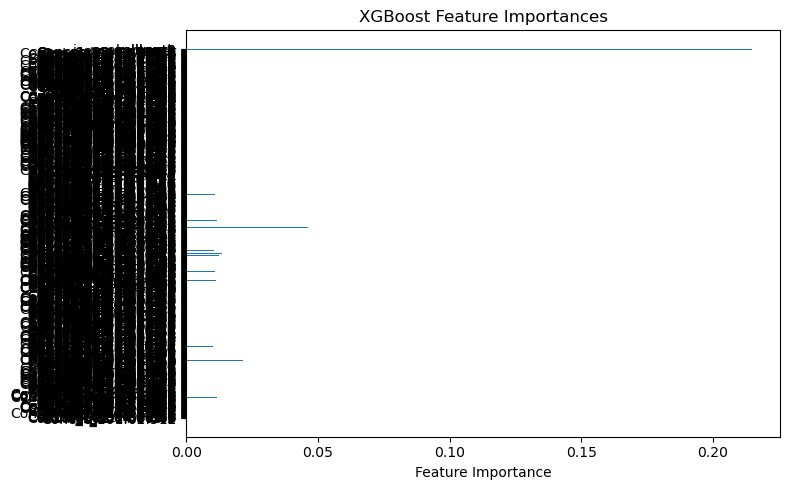

In [49]:
importance = best_model.feature_importances_
for name, score in zip(X.columns, importance):
    print(f"{name}: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.barh(X.columns, importance)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [50]:
print("Train R2:", r2_score(y_train,best_model.predict(X_train)))
print("Test R2:", r2_score(y_test, best_model.predict(X_test)))

Train R2: 0.5672159545757636
Test R2: 0.5368853937366094


In [6]:
#data

In [52]:
y_test

2466    2.078441
2467    2.334278
2468    2.851515
2469    2.078441
2470    0.874635
          ...   
3069    2.400347
3070    1.237214
3071    2.922409
3072    2.538605
3073    1.921471
Name: log_qty, Length: 608, dtype: float64

In [53]:
y_pred

array([1.9891282 , 2.3044236 , 2.7477849 , 2.1227076 , 2.0805264 ,
       0.7215716 , 0.7192523 , 1.7339408 , 1.765103  , 1.765103  ,
       1.765103  , 1.8627627 , 1.8627627 , 1.7833955 , 1.868178  ,
       2.461692  , 1.7339408 , 1.7339408 , 1.7339408 , 1.7388595 ,
       2.7871177 , 2.1258438 , 1.7388595 , 1.9049655 , 1.8145577 ,
       3.4533272 , 1.7833955 , 1.3222861 , 1.7339408 , 1.7339408 ,
       1.5959741 , 1.7833955 , 0.7409586 , 1.7833955 , 1.0550722 ,
       2.1258438 , 1.6894048 , 2.0805264 , 2.2467122 , 1.8894899 ,
       1.4089706 , 1.5107474 , 1.9065114 , 1.5771236 , 0.76465   ,
       1.5781872 , 1.2000021 , 1.1829139 , 1.2962959 , 1.3201607 ,
       2.0810268 , 2.4722505 , 2.1598105 , 1.5053699 , 2.7393575 ,
       2.7223456 , 2.3991625 , 1.7035006 , 1.8977364 , 1.878246  ,
       1.869853  , 1.7819773 , 2.4342575 , 1.5687852 , 1.5959741 ,
       1.7339408 , 1.5771236 , 1.2788494 , 1.5311244 , 1.105119  ,
       1.7339408 , 2.1751971 , 1.4707763 , 1.789362  , 1.54126

In [54]:
h=np.exp(data['lag_1'])

In [55]:
f=np.exp(y_test)

In [56]:
g= np.exp(y_pred)

In [ ]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
data['Concat'] = data[[col for col in data.columns if col.startswith('Concat_')]].idxmax(axis=1).str.replace('Concat_', '')
recent_data = data.sort_values(['Concat', 'year', 'month'])
all_category_material_pairs = data[['Concat', 'MATERIAL DESC.']].drop_duplicates().values.tolist()

last_month = recent_data[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).iloc[-1]
start_date = datetime(int(last_month['year']), int(last_month['month']), 1)

future_preds = []

working_data = recent_data.copy()


target_date = start_date + relativedelta(months=1)
month, year = target_date.month, target_date.year

filled_rows = []

for cat, mat_desc in all_category_material_pairs:
    group = working_data[(working_data['Concat'] == cat) & (working_data['MATERIAL DESC.'] == mat_desc)].copy()
    group = group.sort_values(['year', 'month'])

    if group.empty:
        continue

    latest = group.iloc[-1]

    lag_1 = latest['log_qty']
    lag_2 = group.iloc[-2]['log_qty'] if len(group) > 1 else lag_1
    rolling_2 = group['log_qty'].tail(2).mean()
    rolling_3 = group['log_qty'].tail(3).mean()

    row = {
        'Concat': cat,
        'MATERIAL DESC.': mat_desc,
        'month': month,
        'year': year,
        'lag_1': lag_1,
        'lag_2': lag_2,
        'rolling_2': rolling_2,
        'rolling_3': rolling_3,
        'is_peak_month': int(month in [2, 3, 10])
    }
    for c in data.columns:
        if c.startswith('Concat_'):
            row[c] = 1 if c == f'Concat_{cat}' else 0

    for feat in features:
        if feat not in row:
            row[feat] = 0

    filled_rows.append(row)


    month_input = pd.DataFrame(filled_rows)[features]
    preds = best_model.predict(month_input)
    pred_df1 = pd.DataFrame(filled_rows)
    pred_df1['Predicted Order Qty'] = np.expm1(preds)
    pred_df1['month'] = month
    pred_df1['year'] = year
    print(pred_df1[['MATERIAL DESC.','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']])

In [57]:
pred_df1

In [58]:
aprilpred= pred_df1[['MATERIAL DESC.','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']]

In [59]:
aprilpred

In [60]:
aprilpred.to_excel("AprilPrediction.xlsx", index=False)

In [61]:
aprilpred.to_csv("Aprilprediction.csv", index=False, encoding='utf-8')

test_indices = june_input.index
category_cols = [col for col in data.columns if col.startswith("Concat_")]
category_data_test = data.loc[test_indices, category_cols]
category_names = category_data_test.idxmax(axis=1).str.replace('Concat_', '')
month_col = data.loc[test_indices, 'month']
lag_1 = data.loc[test_indices, 'lag_1']
lag_2 = data.loc[test_indices, 'lag_2']
rolling_2 = data.loc[test_indices, 'rolling_2']
rolling_3 = data.loc[test_indices, 'rolling_3']
year_col = data.loc[test_indices, 'year']
results = pd.DataFrame({
    'category': category_names,
    'month': month_col.values,
    'lag_1': lag_1.values,
    'lag_2': lag_2.values,
    'rolling_2': rolling_2.values,
    'rolling_3': rolling_3.values,
    'year': year_col.values,
})

In [62]:
#results.to_csv("output.csv", index=False, encoding='utf-8')

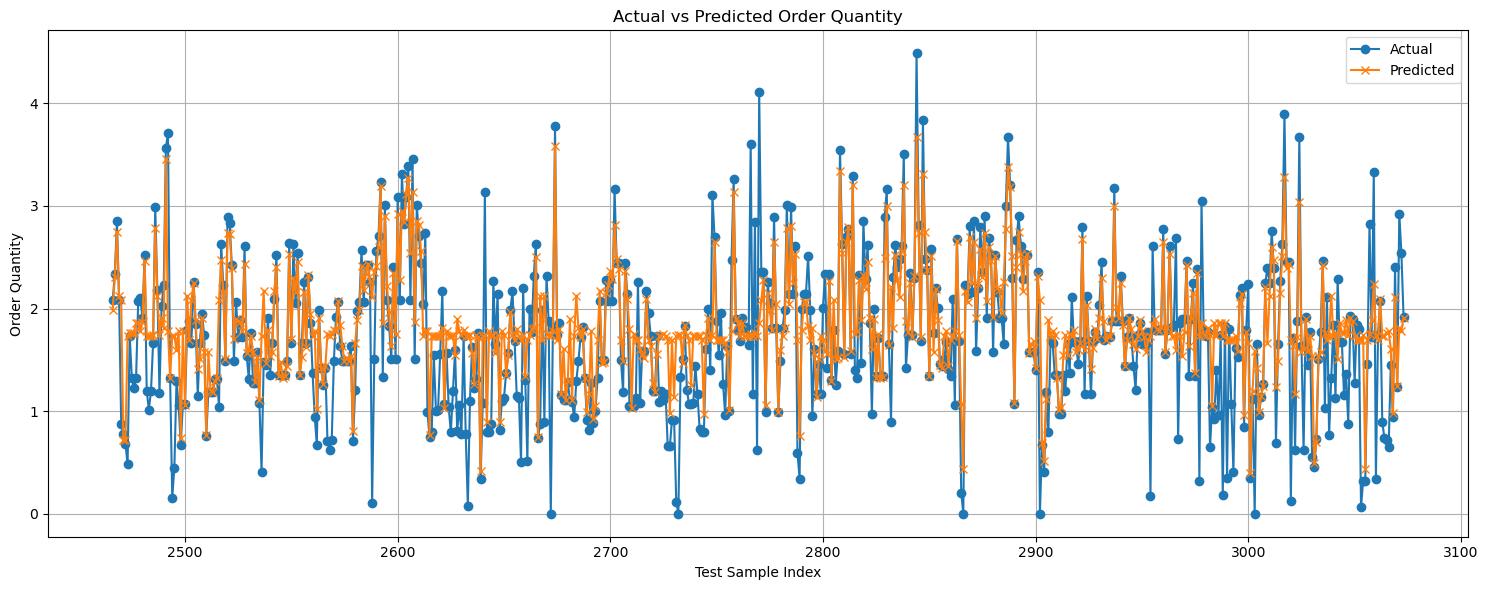

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.plot(X_test.index, y_test, label="Actual", marker='o')
plt.plot(X_test.index, y_pred, label="Predicted", marker='x')
plt.title("Actual vs Predicted Order Quantity")
plt.xlabel("Test Sample Index")
plt.ylabel("Order Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
test_indices = X_test.index
material_desc = data.loc[test_indices, 'MATERIAL DESC.']
material = data.loc[test_indices, 'Material']
category_cols = [col for col in data.columns if col.startswith("Concat_")]
category_data_test = data.loc[test_indices, category_cols]
category_names = category_data_test.idxmax(axis=1).str.replace('Concat_', '')
month_col = data.loc[test_indices, 'month']
lag_1 = data.loc[test_indices, 'lag_1']
lag_2 = data.loc[test_indices, 'lag_2']
rolling_2 = data.loc[test_indices, 'rolling_2']
rolling_3 = data.loc[test_indices, 'rolling_3']
year_col = data.loc[test_indices, 'year']
results_df = pd.DataFrame({
    'category': category_names,
    'MATERIAL DESC.': material_desc.values,
    'Material': material.values,
    'month': month_col.values,
    'lag_1': lag_1.values,
    'lag_2': lag_2.values,
    'rolling_2': rolling_2.values,
    'rolling_3': rolling_3.values,
    'year': year_col.values,
    'y_test': f.values,
    'y_pred': g
})

In [7]:
#print(results_df)

In [66]:
results_df.to_csv("model_output.csv", index=False, encoding='utf-8')

In [67]:
results_df.to_excel("output.xlsx", index=False)

FOR 3 MONTHS

In [68]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

data['Concat'] = data[[col for col in data.columns if col.startswith('Concat_')]].idxmax(axis=1).str.replace('Concat_', '')
recent_data = data.sort_values(['Concat', 'year', 'month'])
all_category_material_pairs = data[['Concat', 'MATERIAL DESC.']].drop_duplicates().values.tolist()

last_month = recent_data[['year', 'month']].drop_duplicates().sort_values(['year', 'month']).iloc[-1]
start_date = datetime(int(last_month['year']), int(last_month['month']), 1)

future_preds = []

working_data = recent_data.copy()

for i in range(1, 4): 
    target_date = start_date + relativedelta(months=i)
    month, year = target_date.month, target_date.year

    filled_rows = []

    for cat, mat_desc in all_category_material_pairs:
        group = working_data[(working_data['Concat'] == cat) & (working_data['MATERIAL DESC.'] == mat_desc)].copy()
        group = group.sort_values(['year', 'month'])

        if group.empty:
            continue

        latest = group.iloc[-1]

        lag_1 = latest['log_qty']
        lag_2 = group.iloc[-2]['log_qty'] if len(group) > 1 else lag_1
        rolling_2 = group['log_qty'].tail(2).mean()
        rolling_3 = group['log_qty'].tail(3).mean()

        row = {
            'Concat': cat,
            'MATERIAL DESC.': mat_desc,
            'month': month,
            'year': year,
            'lag_1': lag_1,
            'lag_2': lag_2,
            'rolling_2': rolling_2,
            'rolling_3': rolling_3,
            'is_peak_month': int(month in [2, 3, 10])
        }
        for c in data.columns:
            if c.startswith('Concat_'):
                row[c] = 1 if c == f'Concat_{cat}' else 0

        for feat in features:
            if feat not in row:
                row[feat] = 0

        filled_rows.append(row)

    month_input = pd.DataFrame(filled_rows)[features]
    preds = best_model.predict(month_input)
    pred_df = pd.DataFrame(filled_rows)
    pred_df['Predicted Order Qty'] = np.expm1(preds)
    pred_df['month'] = month
    pred_df['year'] = year

 
    future_preds.append(pred_df)

    temp_append = pred_df[['Concat', 'MATERIAL DESC.', 'month', 'year', 'Predicted Order Qty']].copy()
    temp_append['log_qty'] = np.log1p(temp_append['Predicted Order Qty'])
    working_data = pd.concat([working_data, temp_append], ignore_index=True)
    
final_future_preds = pd.concat(future_preds, ignore_index=True)

total_3month_qty = final_future_preds.groupby(['Concat', 'MATERIAL DESC.'])['Predicted Order Qty'].sum().reset_index()

In [69]:
last_month

year     2025
month       3
Name: 72, dtype: int32

In [8]:
#total_3month_qty 

In [9]:
#future_preds

In [72]:
final_future_preds= final_future_preds[['MATERIAL DESC.','Concat','month','year','is_peak_month','lag_1','lag_2','rolling_2','rolling_3','Predicted Order Qty']]

In [73]:
final_future_preds.to_csv("3months.csv", index=False, encoding='utf-8')

In [74]:
final_future_preds.to_excel("3months.xlsx", index=False)